## Start Date: 12.01.2026
## model: yolov8n
## Dataset: car-object-detection

In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-object-detection/data/sample_submission.csv
/kaggle/input/car-object-detection/data/train_solution_bounding_boxes (1).csv
/kaggle/input/car-object-detection/data/testing_images/vid_5_26420.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_31520.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_29420.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_31720.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_26560.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_27840.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_28560.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_28360.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_25240.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_29560.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_29020.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_30720.jpg
/kaggle/

In [72]:
from ultralytics import YOLO

# Data Exploration

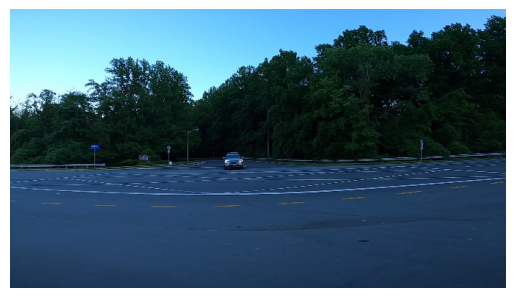

In [73]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/kaggle/working/car-object-detection/data/training_images/vid_4_1000.jpg"
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [74]:
# size of the image
width, height = img.size

# Data Preparation

In [64]:
# copy the origianl dataset to my workspace
# !cp -r /kaggle/input/car-object-detection /kaggle/working/car-object-detection

In [80]:
# "handling csv containing the labels"
# should convert into {image_name}.txt file
# the order:
# <class_id> <x_center> <y_center> <width> <height>
# width, height: size of the bounding box
# should be normalized
import csv

path = "/kaggle/working/car-object-detection"
label_csv_path = os.path.join(path, "data/train_solution_bounding_boxes (1).csv")
label_dir = os.path.join(path, "labels")
os.makedirs(label_dir, exist_ok = True)

with open(label_csv_path, 'r') as f1:
    reader = csv.reader(f1)
    next(reader) # skip the header
    for row in reader:
        # cols = row.strip().split() # no needed, reader already did it
        # row : list
        class_id = 0
        img_name = row[0]
        img_name = img_name.split('.')[0]
        xmin, ymin, xmax, ymax = map(float, row[1:])
        # should be normoalized (label rule of YOLO)
        x_center = ((xmax + xmin) / 2) / width
        y_center = ((ymax + ymin) / 2) / height
        w = (xmax - xmin) / width
        h = (ymax - ymin) / height
        with open(os.path.join(label_dir, img_name + ".txt"), 'w') as f2:
            f2.write(f'{class_id} {x_center} {y_center} {w} {h}')

In [25]:
# Since this dataset doesnt have validation dataset,
# better to divide the training set into training and validation
path = "/kaggle/working/car-object-detection/data"
train_dir = os.path.join(path, "training_images")
test_dir = os.path.join(path, "testing_images")
val_dir = os.path.join(path, "val_images")

# exist_ok = True:
# if the file exists -> nothing happens
# if not -> create the dir
os.makedirs(val_dir, exist_ok = True)

import random, shutil
# the list of names of folders in this dir
images = os.listdir(train_dir)
random.shuffle(images)

split = int(0.8 * len(images))
val_images = images[split:] # 8:2 = training:test

for img in val_images:
    # move the file from ~ to ~
    shutil.move(os.path.join(train_dir, img), val_dir)


In [26]:
%%writefile dataset.yaml
path: /kaggle/working/car-object-detection
train: data/training_images
test: data/testing_images
val: data/val_images
names:
    0: car

Overwriting dataset.yaml


In [27]:
model = YOLO('yolov8n.pt')

In [10]:
# YOLO is based on CNN, input must be square shaped
# imgsz = 640 :
# The input data is reshaped into 640 x 640
model.train(data='dataset.yaml', epochs=10, imgsz=640)

Ultralytics 8.3.252 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretraine

RuntimeError: Dataset 'dataset.yaml' error ❌ dataset.yaml 'val:' key missing ❌.
'train' and 'val' are required in all data YAMLs.